<a href="https://colab.research.google.com/github/kayorde25/Satellite-image-classification-and-clustering/blob/main/updated_satellite_embedding_benchmark_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Satellite Image Embedding Benchmarking and Clustering

## Overview
This notebook upgrades the project from a simple clustering demo into a small benchmark baseline for satellite-image embeddings.

## Notebook
- Loads the EuroSAT dataset
- Extracts image embeddings using pretrained ResNet50
- Standardizes and reduces dimensions with PCA
- Clusters embeddings with **KMeans** and **HDBSCAN**
- Evaluates clustering using **ARI**, **NMI**, and **silhouette score**
- Visualizes clusters with **UMAP**
- Saves figures and results tables on GitHub repo


In [1]:
# Install required packages in Google Colab.
# hdbscan is included so we can compare a centroid-based method (KMeans)
# with a density-based method (HDBSCAN).

!pip install -q torch torchvision scikit-learn umap-learn matplotlib pandas numpy hdbscan


## Step 1: Import libraries

We import:
- PyTorch for feature extraction
- torchvision for EuroSAT and pretrained ResNet50
- scikit-learn for scaling, PCA, clustering metrics, and KMeans
- hdbscan for density-based clustering
- UMAP for 2D visualization
- matplotlib and pandas for outputs


In [2]:
import os
import warnings

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)

import umap
import hdbscan

warnings.filterwarnings("ignore")


## Step 2: Create output folders


In [3]:
os.makedirs("/content/outputs/figures", exist_ok=True)
os.makedirs("/content/outputs/tables", exist_ok=True)

print("Output folders created:")
print("/content/outputs/figures")
print("/content/outputs/tables")


Output folders created:
/content/outputs/figures
/content/outputs/tables


## Step 3: Check device

A GPU speeds up embedding extraction.


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


## Step 4: Define image transforms

We resize to 224×224 because pretrained ResNet50 expects this input size.
We also convert images to tensors so PyTorch can process them.


In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


## Step 5: Load EuroSAT

EuroSAT is a popular remote-sensing benchmark derived from Sentinel-2 imagery.
It gives us labeled satellite images, which lets us evaluate clustering quality.


In [6]:
dataset = datasets.EuroSAT(
    root="/content/data",
    download=True,
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("Dataset size:", len(dataset))
print("Classes:", dataset.classes)


100%|██████████| 94.3M/94.3M [00:00<00:00, 372MB/s]


Dataset size: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Step 6: Visualize sample images

This quick check confirms the dataset loaded correctly and gives us a feel for the classes.


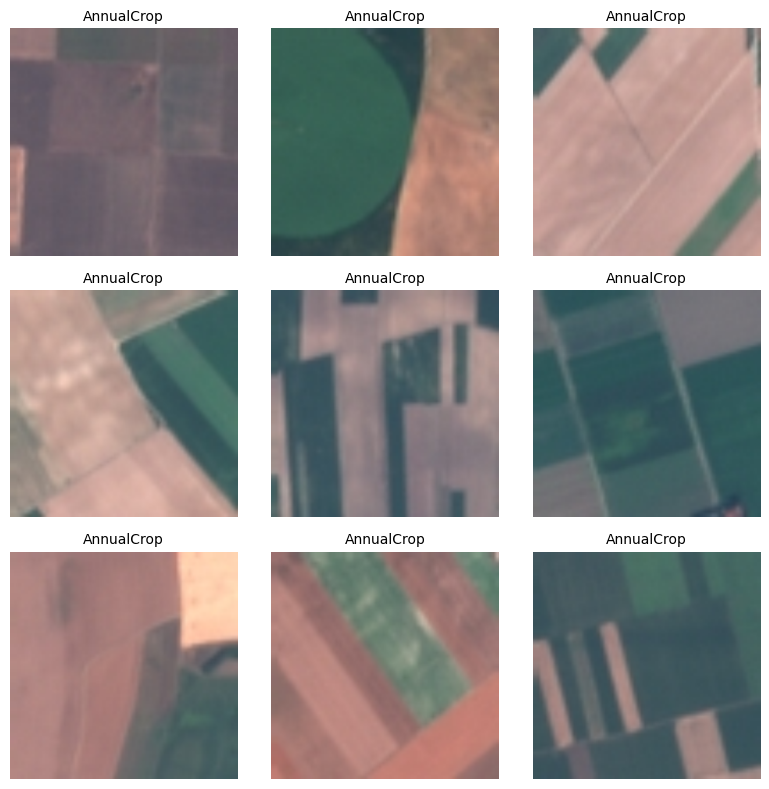

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
axes = axes.ravel()

for i in range(9):
    img, label = dataset[i]
    img = img.permute(1, 2, 0).numpy()

    axes[i].imshow(img)
    axes[i].set_title(dataset.classes[label], fontsize=10)
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## Step 7: Load pretrained ResNet50 as an embedding extractor

We remove the final classification layer so the model returns a feature vector
instead of class probabilities.

This lets us use the model for **representation learning / embeddings** rather than classification.


In [8]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Remove the final classifier so the network outputs a 2048-dimensional embedding.
model.fc = nn.Identity()

model = model.to(device)
model.eval()

print("ResNet50 embedding model ready.")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 118MB/s]


ResNet50 embedding model ready.


## Step 8: Extract embeddings

Each image is converted into a 2048-dimensional feature vector.
These embeddings are what we cluster.


In [9]:
all_embeddings = []
all_labels = []

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        feats = model(images)

        all_embeddings.append(feats.cpu().numpy())
        all_labels.append(labels.numpy())

        if batch_idx % 100 == 0:
            print(f"Processed batch {batch_idx}/{len(loader)}")

X = np.vstack(all_embeddings)
y = np.hstack(all_labels)

print("Embedding matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Processed batch 0/844
Processed batch 100/844
Processed batch 200/844
Processed batch 300/844
Processed batch 400/844
Processed batch 500/844
Processed batch 600/844
Processed batch 700/844
Processed batch 800/844
Embedding matrix shape: (27000, 2048)
Label vector shape: (27000,)


## Step 9: Standardize embeddings

Scaling helps prevent a few large-magnitude features from dominating PCA and clustering.


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled embedding shape:", X_scaled.shape)


Scaled embedding shape: (27000, 2048)


## Step 10: Reduce dimensions with PCA

The raw embedding space has 2048 dimensions, which is often noisy for clustering.
PCA compresses the data while preserving much of the useful variance.


In [11]:
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_.sum()

print("PCA output shape:", X_pca.shape)
print(f"Total explained variance by 50 components: {explained_variance:.4f}")


PCA output shape: (27000, 50)
Total explained variance by 50 components: 0.3979


## Step 11: Visualize embeddings in 2D with UMAP

UMAP is used only for visualization.
We cluster in PCA space, but we plot in 2D so humans can inspect the structure.


In [12]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_2d = reducer.fit_transform(X_pca)

print("UMAP output shape:", X_2d.shape)


UMAP output shape: (27000, 2)


## Step 12: Baseline clustering with KMeans

### Why use KMeans?
KMeans is a strong baseline because it is simple, fast, and easy to interpret.

### Limitation
It requires us to predefine the number of clusters and forces every point into a cluster.


In [13]:
kmeans = KMeans(
    n_clusters=10,   # EuroSAT has 10 labeled classes, so this is a sensible baseline
    random_state=42,
    n_init=10
)

clusters_kmeans = kmeans.fit_predict(X_pca)

print("KMeans cluster labels:", np.unique(clusters_kmeans))


KMeans cluster labels: [0 1 2 3 4 5 6 7 8 9]


## Step 13: Evaluate KMeans

We use:
- **ARI**: agreement with true labels
- **NMI**: shared information between labels and clusters
- **Silhouette**: internal cluster separation


In [14]:
ari_kmeans = adjusted_rand_score(y, clusters_kmeans)
nmi_kmeans = normalized_mutual_info_score(y, clusters_kmeans)
sil_kmeans = silhouette_score(X_pca, clusters_kmeans)

print(f"KMeans ARI: {ari_kmeans:.4f}")
print(f"KMeans NMI: {nmi_kmeans:.4f}")
print(f"KMeans Silhouette: {sil_kmeans:.4f}")


KMeans ARI: 0.5898
KMeans NMI: 0.6325
KMeans Silhouette: 0.1180


## Step 14: Visualize KMeans clusters

We save the plot so it can be added directly to the repo under `outputs/figures/`.


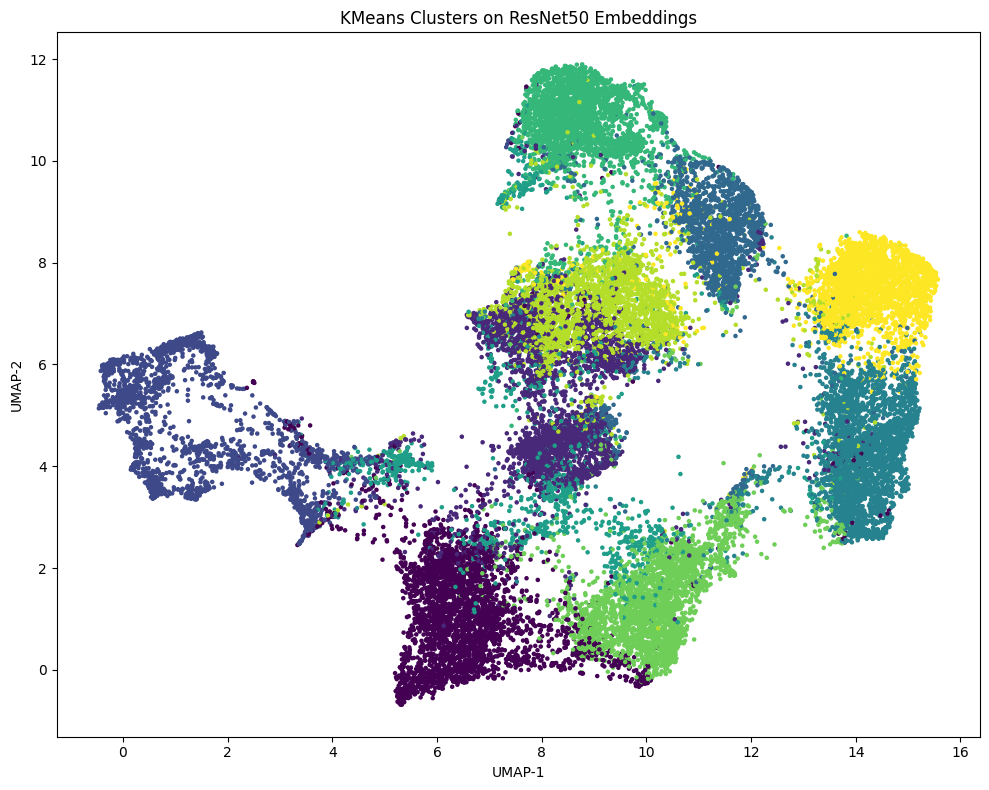

In [15]:
plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters_kmeans, s=5)
plt.title("KMeans Clusters on ResNet50 Embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.savefig("/content/outputs/figures/kmeans_umap.png", dpi=300, bbox_inches="tight")
plt.show()


## Step 15: Compare with HDBSCAN

### Why HDBSCAN is often superior to KMeans for embeddings
HDBSCAN is frequently better for real embedding spaces because:

- it **does not require** the number of clusters in advance
- it can handle **irregular cluster shapes**
- it works better when clusters have **different densities**
- it can mark uncertain points as **noise** instead of forcing them into clusters

This is especially useful in satellite imagery, where some tiles are mixed or ambiguous.


In [16]:
hdb = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10
)

clusters_hdb = hdb.fit_predict(X_pca)

print("HDBSCAN labels:", np.unique(clusters_hdb))
print("Noise points:", np.sum(clusters_hdb == -1))


HDBSCAN labels: [-1  0  1  2  3]
Noise points: 24308


## Step 16: Evaluate HDBSCAN

For silhouette score, we exclude noise points labeled `-1`.


In [17]:
ari_hdb = adjusted_rand_score(y, clusters_hdb)
nmi_hdb = normalized_mutual_info_score(y, clusters_hdb)

mask = clusters_hdb != -1

if mask.sum() > 1 and len(np.unique(clusters_hdb[mask])) > 1:
    sil_hdb = silhouette_score(X_pca[mask], clusters_hdb[mask])
else:
    sil_hdb = np.nan

print(f"HDBSCAN ARI: {ari_hdb:.4f}")
print(f"HDBSCAN NMI: {nmi_hdb:.4f}")
print(f"HDBSCAN Silhouette: {sil_hdb:.4f}")


HDBSCAN ARI: 0.0141
HDBSCAN NMI: 0.1722
HDBSCAN Silhouette: 0.6162


## Step 17: Visualize HDBSCAN clusters

This helps us inspect whether HDBSCAN produces more natural grouping than KMeans.


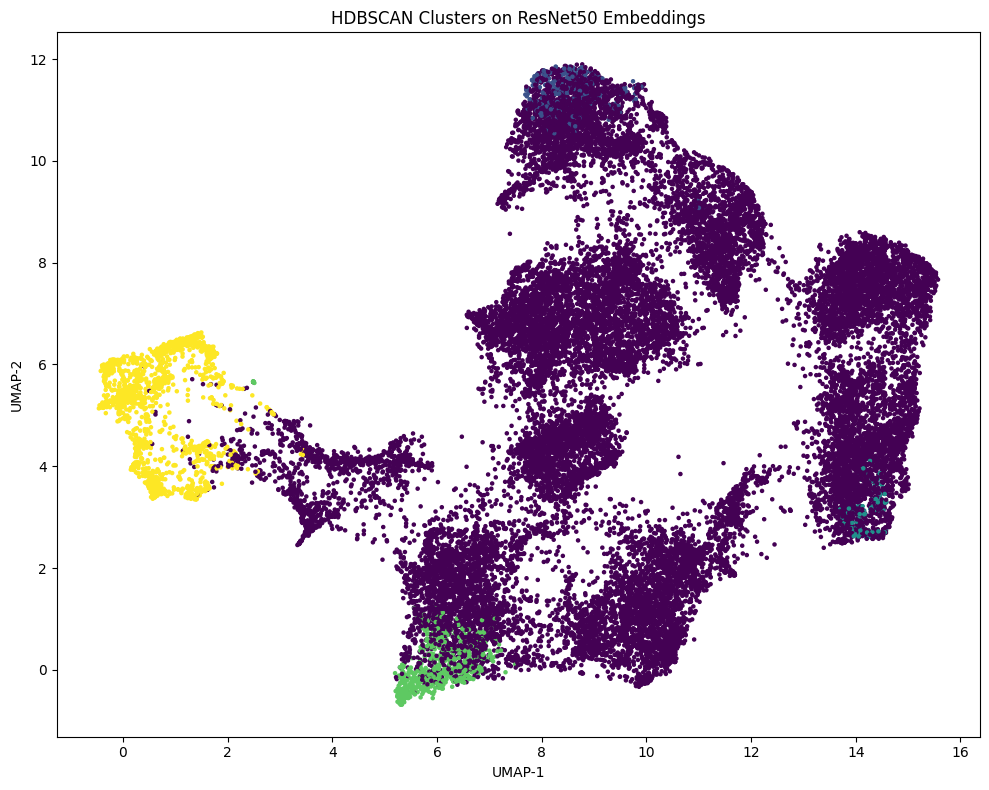

In [18]:
plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters_hdb, s=5)
plt.title("HDBSCAN Clusters on ResNet50 Embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.savefig("/content/outputs/figures/hdbscan_umap.png", dpi=300, bbox_inches="tight")
plt.show()


## Step 18: Plot true labels for comparison

This lets us visually compare the true class structure against the clustering results.


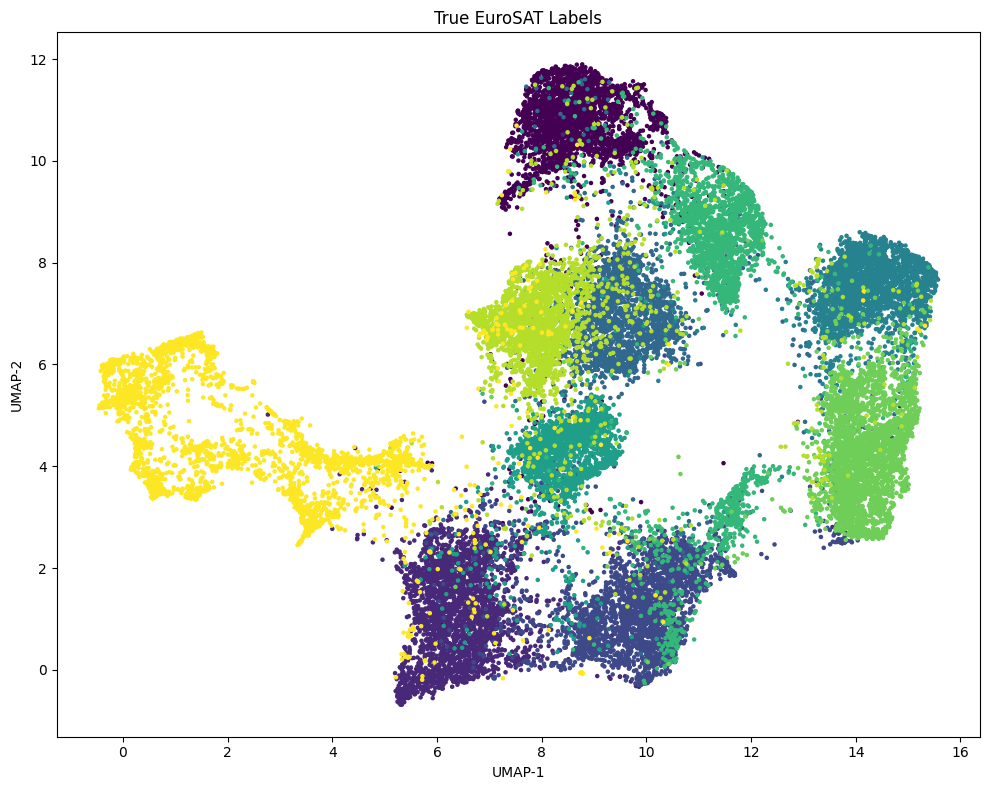

In [19]:
plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, s=5)
plt.title("True EuroSAT Labels")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.savefig("/content/outputs/figures/true_labels_umap.png", dpi=300, bbox_inches="tight")
plt.show()


## Step 19: Inspect sample images from a cluster

Qualitative inspection is important because metrics alone do not tell the whole story.


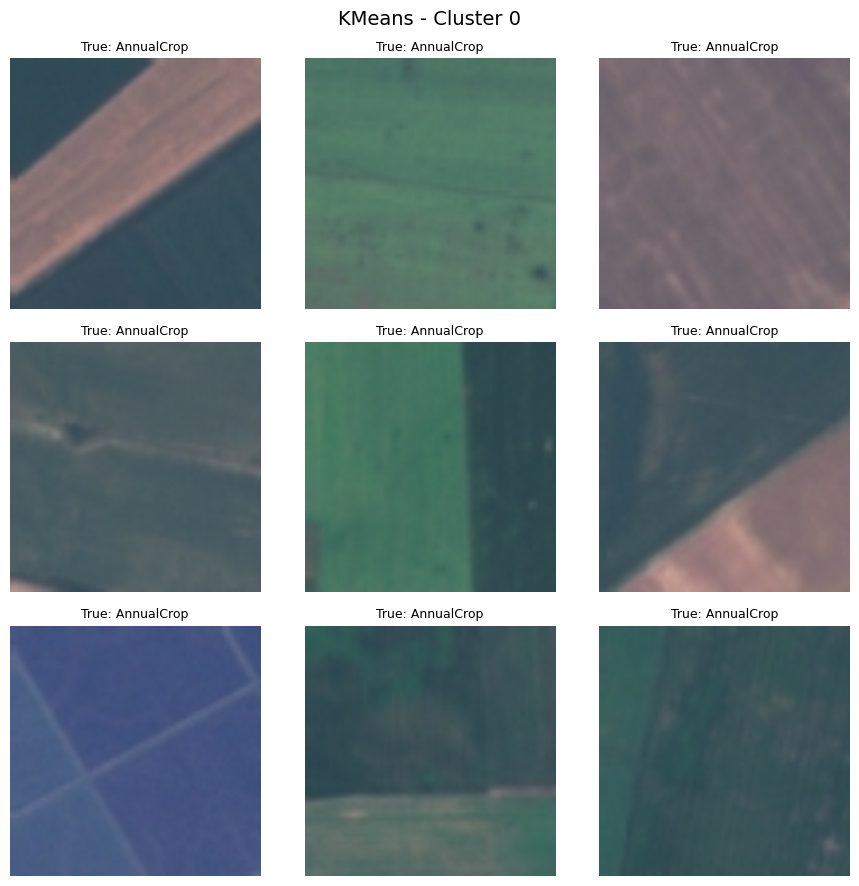

In [20]:
def show_cluster_examples(dataset, cluster_assignments, cluster_id, title_prefix, n=9):
    indices = np.where(cluster_assignments == cluster_id)[0]
    n = min(n, len(indices))

    if n == 0:
        print(f"No samples found for cluster {cluster_id}")
        return

    rows = int(np.ceil(n / 3))
    fig, axes = plt.subplots(rows, 3, figsize=(9, 3 * rows))
    axes = np.array(axes).reshape(-1)

    for i in range(n):
        idx = indices[i]
        image, label = dataset[idx]
        image_np = image.permute(1, 2, 0).numpy()

        axes[i].imshow(image_np)
        axes[i].set_title(f"True: {dataset.classes[label]}", fontsize=9)
        axes[i].axis("off")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"{title_prefix} - Cluster {cluster_id}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Example inspection
show_cluster_examples(dataset, clusters_kmeans, cluster_id=0, title_prefix="KMeans", n=9)


## Step 20: Build benchmark results table

This table is the core artifact that makes the project look like a benchmark rather than a one-off notebook.


In [21]:
results_df = pd.DataFrame([
    {
        "model": "ResNet50",
        "clustering": "KMeans",
        "ARI": ari_kmeans,
        "NMI": nmi_kmeans,
        "Silhouette": sil_kmeans,
        "NoisePoints": 0,
    },
    {
        "model": "ResNet50",
        "clustering": "HDBSCAN",
        "ARI": ari_hdb,
        "NMI": nmi_hdb,
        "Silhouette": sil_hdb,
        "NoisePoints": int(np.sum(clusters_hdb == -1)),
    }
])

results_df


,model,clustering,ARI,NMI,Silhouette,NoisePoints
0,ResNet50,KMeans,0.589810,0.632497,0.117960,0
1,ResNet50,HDBSCAN,0.014125,0.172172,0.616226,24308


## Step 21: Save benchmark table and detailed assignments

These files can be committed to the repo inside `outputs/tables/`.


In [22]:
results_df.to_csv("/content/outputs/tables/benchmark_results.csv", index=False)

assignment_df = pd.DataFrame({
    "true_label": y,
    "true_class_name": [dataset.classes[label] for label in y],
    "kmeans_cluster": clusters_kmeans,
    "hdbscan_cluster": clusters_hdb,
    "umap_x": X_2d[:, 0],
    "umap_y": X_2d[:, 1],
})

assignment_df.to_csv("/content/outputs/tables/cluster_assignments.csv", index=False)

print("Saved:")
print("/content/outputs/tables/benchmark_results.csv")
print("/content/outputs/tables/cluster_assignments.csv")


Saved:
/content/outputs/tables/benchmark_results.csv
/content/outputs/tables/cluster_assignments.csv


## Step 22: Download block for Colab

Download outputs directly from Colab.


In [23]:
from google.colab import files
files.download("/content/outputs/tables/benchmark_results.csv")
files.download("/content/outputs/tables/cluster_assignments.csv")
files.download("/content/outputs/figures/kmeans_umap.png")
files.download("/content/outputs/figures/hdbscan_umap.png")
files.download("/content/outputs/figures/true_labels_umap.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

This notebook includes:
- a clear embedding-based workflow
- a baseline benchmark
- **KMeans vs HDBSCAN**
- quantitative evaluation
- saved figures and tables

